In [1]:
# 1) Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [94]:
# 2) import dataframe
df=pd.read_csv("C:/Users/Selva.M/Downloads/data_science/mini_projects/project_5/chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2024-09-06,Claim who accept.,Every quite sense including six lot have never...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No
1,3/7/2025,Growth pretty wish.,Ask develop bag also his worker pass. Expert w...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes
2,########,What then spend offer reason whom none.,If customer address region try near risk next ...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No
3,########,Say dog drug enter director strong student.,To television loss election him small detail r...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No
4,########,Purpose here beyond.,Pass share must amount lot per manage world to...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No


In [95]:
df.shape

(250, 12)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               250 non-null    object
 1   title              250 non-null    object
 2   review             250 non-null    object
 3   rating             250 non-null    int64 
 4   username           250 non-null    object
 5   helpful_votes      250 non-null    int64 
 6   review_length      250 non-null    int64 
 7   platform           250 non-null    object
 8   language           250 non-null    object
 9   location           250 non-null    object
 10  version            250 non-null    object
 11  verified_purchase  250 non-null    object
dtypes: int64(3), object(9)
memory usage: 23.6+ KB


In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [99]:
df['review']

0      Every quite sense including six lot have never...
1      Ask develop bag also his worker pass. Expert w...
2      If customer address region try near risk next ...
3      To television loss election him small detail r...
4      Pass share must amount lot per manage world to...
                             ...                        
245    Government card history suddenly save theory s...
246    Court control million hundred offer total hit ...
247    Just opportunity ask yet against large practic...
248    Onto simple audience as including claim create...
249    Goal positive bank later behind election these...
Name: review, Length: 250, dtype: object

In [100]:
df["review"].str.contains(r"\d", na=False).sum()

np.int64(0)

In [101]:
df["review"].str.contains(r"[@#\$%&]", na=False).sum()

np.int64(0)

In [102]:
df["review"].str.contains(r"[^\w\s]", na=False).sum()

np.int64(250)

In [103]:
import re

def special(text):
    return re.findall(r"[^\w\s]", text)

df["review"].dropna().apply(special).head()

0    [., .]
1    [., .]
2    [., .]
3    [., .]
4    [., .]
Name: review, dtype: object

In [104]:
df['review'].value_counts().head(10)

review
Every quite sense including six lot have never effect fill general relationship save. Security land record class Democrat hundred full nearly recent.                                              1
Ask develop bag also his worker pass. Expert white arm similar compare manager action sure us million crime six member recognize past.                                                             1
If customer address region try near risk next on girl spring. Paper create upon offer end imagine blood authority family water.                                                                    1
To television loss election him small detail red son include good. Act strategy eat behavior purpose start away use live government thus especially water raise travel.                            1
Pass share must amount lot per manage world to than make worker. Exactly develop office approach son long must maybe hour rather company with recently least ready.                                1
Especial

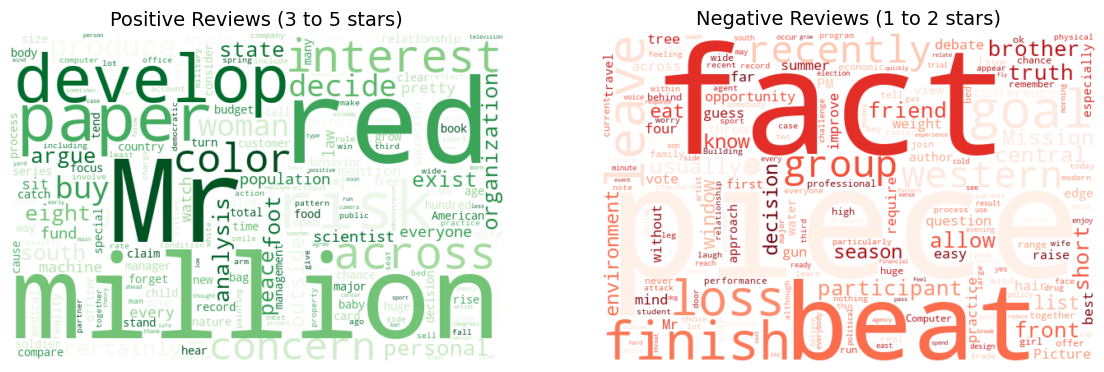

In [13]:
# Most Common Keywords in Positive vs. Negative Reviews
from wordcloud import WordCloud
# Filter based on ratings
positive_reviews = df[df['rating'] >= 3]['review']
negative_reviews = df[df['rating'] <= 2]['review']

# Join all text
positive_text = ' '.join(positive_reviews.dropna().astype(str))
negative_text = ' '.join(negative_reviews.dropna().astype(str))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews (3 to 5 stars)", fontsize=14)

plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews (1 to 2 stars)", fontsize=14)
plt.show()


In [105]:
df['helpful_votes'].value_counts()

helpful_votes
130    5
144    5
167    5
143    4
83     4
      ..
114    1
42     1
5      1
109    1
151    1
Name: count, Length: 146, dtype: int64

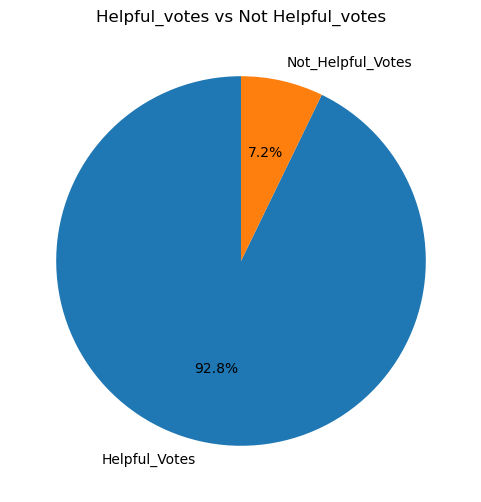

In [106]:
threshold = 10

# Count helpful vs not helpful
helpful_counts = pd.Series([
    'Helpful_Votes' if x > threshold else 'Not_Helpful_Votes' 
    for x in df['helpful_votes']
]).value_counts()

plt.figure(figsize=(6, 6))
helpful_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Helpful_votes vs Not Helpful_votes')
plt.ylabel('')
plt.show()

In [107]:
df['platform'].value_counts()

platform
Amazon         56
App Store      55
Website        54
Flipkart       44
Google Play    41
Name: count, dtype: int64

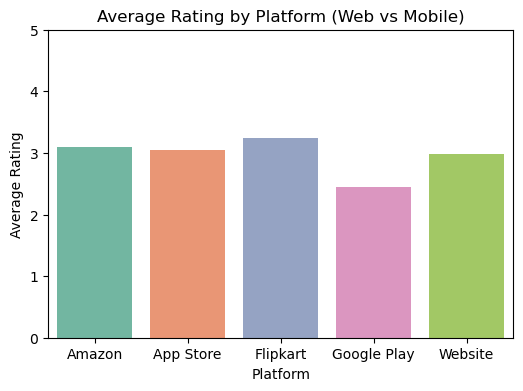

In [108]:
avg_rating_by_platform = df.groupby('platform')['rating'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(x='platform', y='rating', data=avg_rating_by_platform, palette='Set2')
plt.title('Average Rating by Platform (Web vs Mobile)')
plt.ylabel('Average Rating')
plt.xlabel('Platform')
plt.ylim(0,5)
plt.show()

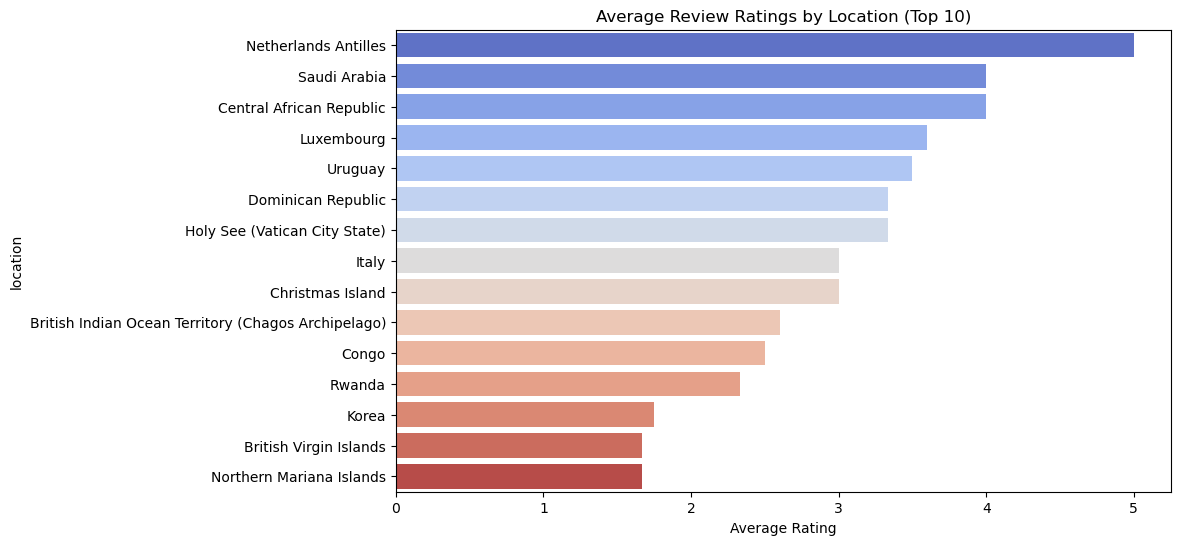

In [109]:
# Top 10 countries by review count
top_countries = df['location'].value_counts().nlargest(15).index
filtered_df = df[df['location'].isin(top_countries)]

# Average rating by location
avg_rating_by_location = filtered_df.groupby('location')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_by_location.values, y=avg_rating_by_location.index, palette="coolwarm")
plt.xlabel('Average Rating')
plt.title('Average Review Ratings by Location (Top 10)')
plt.show()

In [110]:
df['rating'].value_counts().sort_index()

rating
1    59
2    38
3    57
4    41
5    55
Name: count, dtype: int64

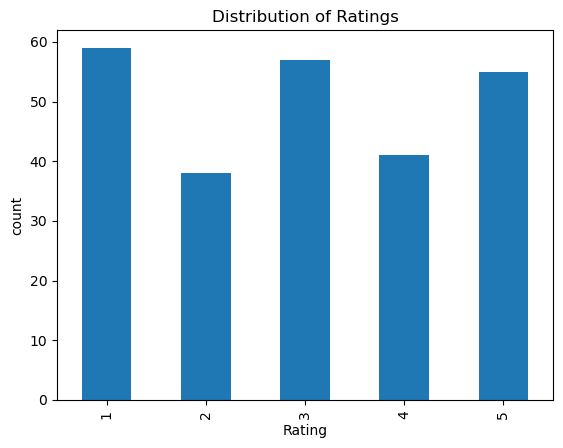

In [111]:
# Distribution of Ratings
df['rating'].value_counts().sort_index().plot(kind = 'bar')
plt.xlabel('Rating')
plt.ylabel('count') 
plt.title('Distribution of Ratings')
plt.show()

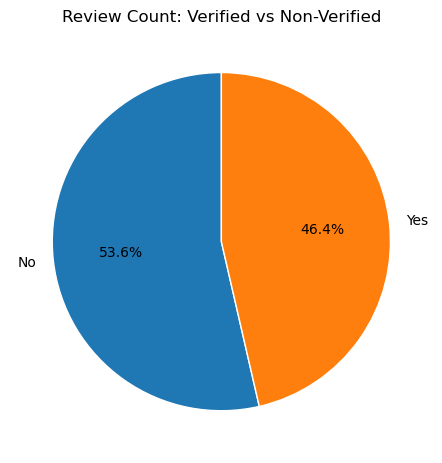

In [112]:
# Distribution of Verified vs Non-Verified Reviews
verified_counts = df['verified_purchase'].value_counts()

# Plotting side-by-side pie charts
plt.figure(figsize=(12, 6))
# Subplot 1: Review count
plt.subplot(1, 2, 1)
verified_counts.plot(kind='pie',autopct='%1.1f%%',startangle=90,labels=verified_counts.index,wedgeprops={'edgecolor': 'white'})
plt.title('Review Count: Verified vs Non-Verified')
plt.ylabel('');

In [113]:
# Create sentiment column based on rating
def create_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return "Positive"
    
df['sentiment'] = df['rating'].apply(create_sentiment)

In [114]:
df['sentiment'].value_counts()

sentiment
Negative    97
Positive    96
Neutral     57
Name: count, dtype: int64

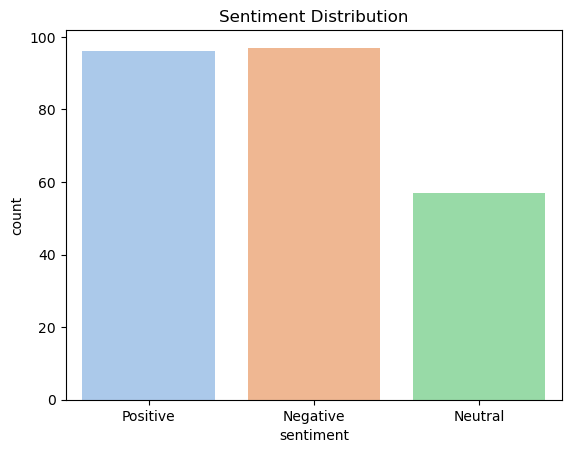

In [115]:
sns.countplot(data=df, x='sentiment', palette='pastel')
plt.title('Sentiment Distribution')
plt.show()

In [116]:
df.groupby('platform')['sentiment'].value_counts()

platform     sentiment
Amazon       Positive     24
             Negative     20
             Neutral      12
App Store    Positive     21
             Negative     17
             Neutral      17
Flipkart     Positive     20
             Negative     13
             Neutral      11
Google Play  Negative     24
             Positive     10
             Neutral       7
Website      Negative     23
             Positive     21
             Neutral      10
Name: count, dtype: int64

In [117]:
df.groupby('verified_purchase')['sentiment'].value_counts()

verified_purchase  sentiment
No                 Negative     53
                   Positive     52
                   Neutral      29
Yes                Negative     44
                   Positive     44
                   Neutral      28
Name: count, dtype: int64

In [118]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [119]:
import re

def clean_text(text):
    text = text.lower() # lowercase
    text = re.sub(r'[^\w\s]', '', text) # remove punctuation
    words = text.split() #tokenize
    words = [lemmatizer.lemmatize(w)
             for w in words
             if w not in stop_words] # remove stopwords and lemmitize
    return ' '.join(words)

In [120]:
df_new = df.copy()

In [121]:
df_new.columns = df_new.columns.str.strip()

In [122]:
df_new['sentiment'].value_counts()

sentiment
Negative    97
Positive    96
Neutral     57
Name: count, dtype: int64

In [123]:
df_new.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
sentiment            0
dtype: int64

In [124]:
df_new['sentiment'] = df_new['sentiment'].map({
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
})

In [125]:
df_new['sentiment'].unique()

array([2, 0, 1])

In [126]:
# Preprocessing...
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df_new['review'] = df_new['review'].apply(clean_text)

In [127]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               250 non-null    object
 1   title              250 non-null    object
 2   review             250 non-null    object
 3   rating             250 non-null    int64 
 4   username           250 non-null    object
 5   helpful_votes      250 non-null    int64 
 6   review_length      250 non-null    int64 
 7   platform           250 non-null    object
 8   language           250 non-null    object
 9   location           250 non-null    object
 10  version            250 non-null    object
 11  verified_purchase  250 non-null    object
 12  sentiment          250 non-null    int64 
dtypes: int64(4), object(9)
memory usage: 25.5+ KB


In [ ]:
# TFIDF Vectorization - Embedding (TF-IDF )
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer= TfidfVectorizer(max_features=1000,ngram_range=(1,2),stop_words='english')

x = df_new['review']
y = df_new['sentiment']

x = vectorizer.fit_transform(x)

In [129]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [131]:
#Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "XGBoost": XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,eval_metric='mlogloss',random_state=42),
    "Svm":LinearSVC(),
}


🔹 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.41      0.55      0.47        20
           1       0.00      0.00      0.00        12
           2       0.35      0.44      0.39        18

    accuracy                           0.38        50
   macro avg       0.25      0.33      0.29        50
weighted avg       0.29      0.38      0.33        50



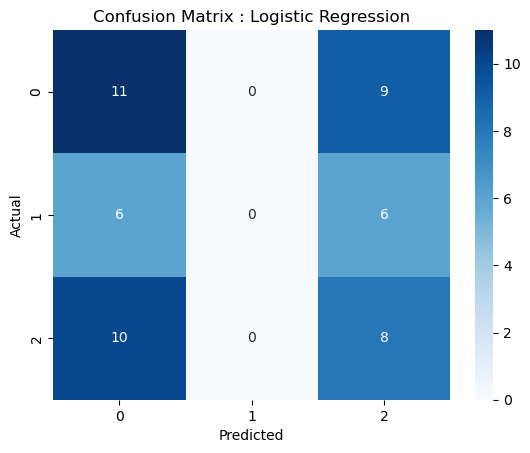


🔹 Model: Random Forest
              precision    recall  f1-score   support

           0       0.46      0.55      0.50        20
           1       0.00      0.00      0.00        12
           2       0.32      0.44      0.37        18

    accuracy                           0.38        50
   macro avg       0.26      0.33      0.29        50
weighted avg       0.30      0.38      0.33        50



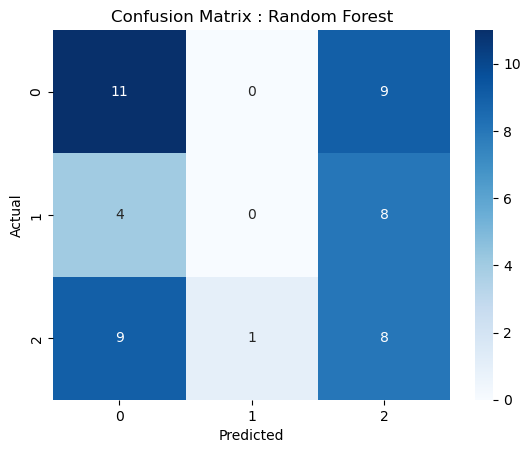


🔹 Model: Naive Bayes
              precision    recall  f1-score   support

           0       0.41      0.60      0.49        20
           1       0.00      0.00      0.00        12
           2       0.38      0.44      0.41        18

    accuracy                           0.40        50
   macro avg       0.26      0.35      0.30        50
weighted avg       0.30      0.40      0.34        50



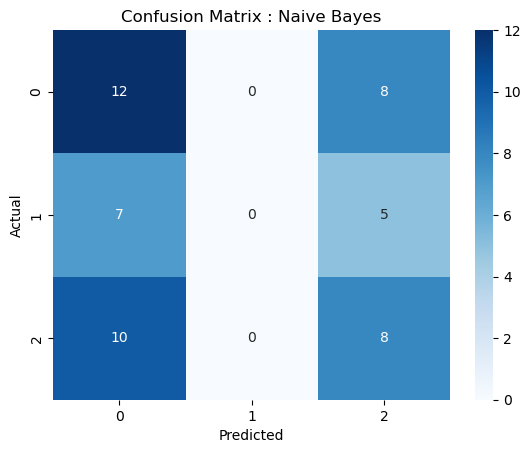


🔹 Model: XGBoost
              precision    recall  f1-score   support

           0       0.58      0.55      0.56        20
           1       0.40      0.17      0.24        12
           2       0.50      0.72      0.59        18

    accuracy                           0.52        50
   macro avg       0.49      0.48      0.46        50
weighted avg       0.51      0.52      0.49        50



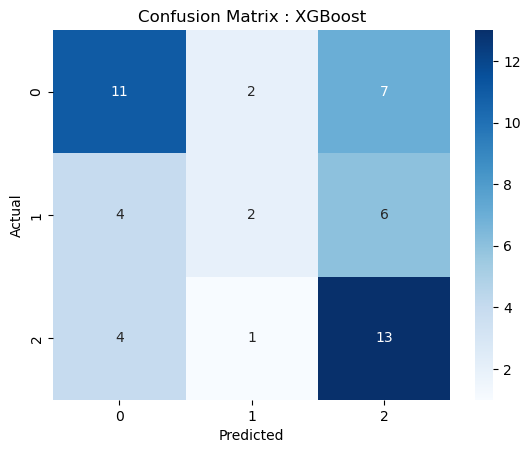


🔹 Model: Svm
              precision    recall  f1-score   support

           0       0.36      0.45      0.40        20
           1       0.50      0.25      0.33        12
           2       0.42      0.44      0.43        18

    accuracy                           0.40        50
   macro avg       0.43      0.38      0.39        50
weighted avg       0.42      0.40      0.40        50



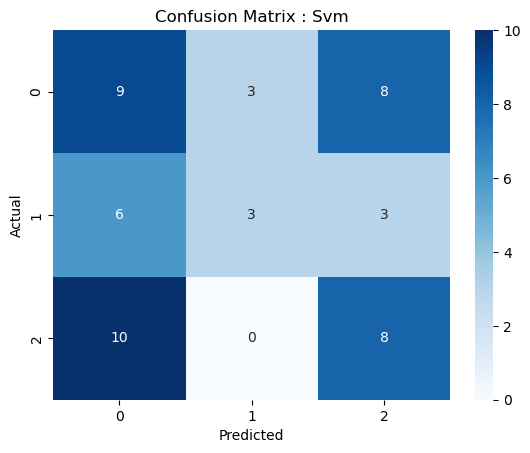

In [132]:
#Model training and evaluation
results = []

for name, model in models.items():
    print(f"\n🔹 Model: {name}")

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print(classification_report(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(x_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix : {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-score (macro)": f1,
        "AUC-ROC (OvR)": auc
    })

In [133]:
#Model Comparison

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score (macro)", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,F1-score (macro),AUC-ROC (OvR)
0,XGBoost,0.52,0.463435,0.567871
1,Svm,0.40,0.388589,NaN
2,Naive Bayes,0.40,0.300017,0.549358
3,Random Forest,0.38,0.290698,0.562652
4,Logistic Regression,0.38,0.286110,0.551983


In [134]:
# OverSample for detter result
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
x_resampled, y_resampled = ros.fit_resample(x, y)

In [135]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=42)

In [136]:
#Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "XGBoost": XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,eval_metric='mlogloss',random_state=42),
    "Svm":LinearSVC(),
}


🔹 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.43      0.43      0.43        14
           1       1.00      0.56      0.72        32
           2       0.30      0.62      0.40        13

    accuracy                           0.54        59
   macro avg       0.57      0.54      0.52        59
weighted avg       0.71      0.54      0.58        59



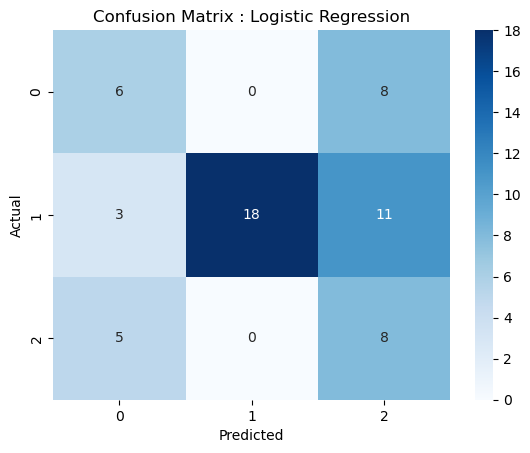


🔹 Model: Random Forest
              precision    recall  f1-score   support

           0       0.44      0.29      0.35        14
           1       0.87      0.62      0.73        32
           2       0.33      0.69      0.45        13

    accuracy                           0.56        59
   macro avg       0.55      0.53      0.51        59
weighted avg       0.65      0.56      0.58        59



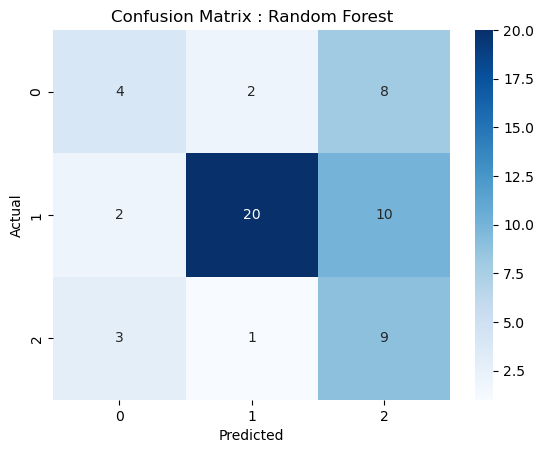


🔹 Model: Naive Bayes
              precision    recall  f1-score   support

           0       0.46      0.43      0.44        14
           1       0.83      0.59      0.69        32
           2       0.30      0.54      0.39        13

    accuracy                           0.54        59
   macro avg       0.53      0.52      0.51        59
weighted avg       0.62      0.54      0.57        59



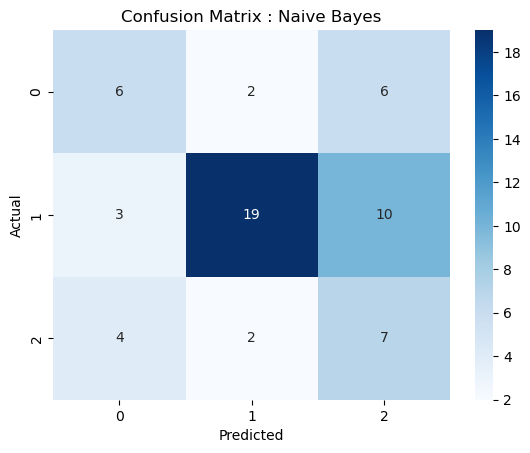


🔹 Model: XGBoost
              precision    recall  f1-score   support

           0       0.40      0.43      0.41        14
           1       0.78      0.56      0.65        32
           2       0.24      0.38      0.29        13

    accuracy                           0.49        59
   macro avg       0.47      0.46      0.45        59
weighted avg       0.57      0.49      0.52        59



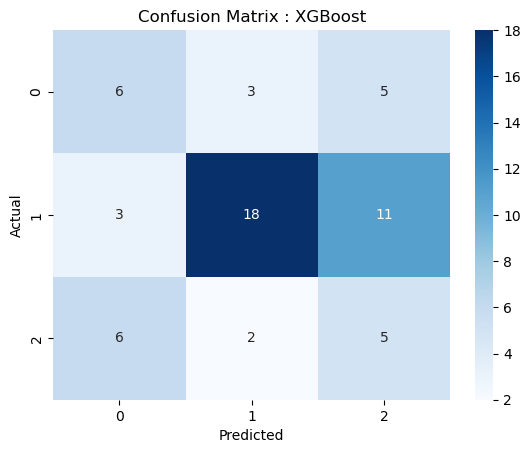


🔹 Model: Svm
              precision    recall  f1-score   support

           0       0.54      0.50      0.52        14
           1       0.88      0.66      0.75        32
           2       0.36      0.62      0.46        13

    accuracy                           0.61        59
   macro avg       0.59      0.59      0.58        59
weighted avg       0.68      0.61      0.63        59



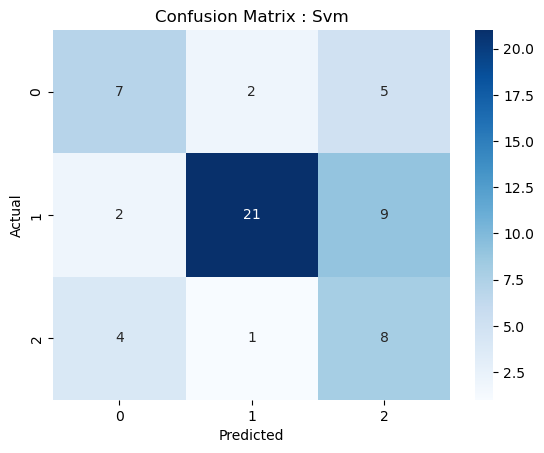

In [137]:
#Model training and evaluation
results = []

for name, model in models.items():
    print(f"\n🔹 Model: {name}")

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print(classification_report(y_test, y_pred))

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(x_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix : {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-score (macro)": f1,
        "AUC-ROC (OvR)": auc
    })

In [138]:
#Model Comparison

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score (macro)", ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,F1-score (macro),AUC-ROC (OvR)
0,Svm,0.610169,0.575220,NaN
1,Logistic Regression,0.542373,0.516190,0.691470
2,Random Forest,0.559322,0.508366,0.667744
3,Naive Bayes,0.542373,0.508081,0.677160
4,XGBoost,0.491525,0.454152,0.660845


In [143]:
df_new.to_csv("cleaned_chatgpt_style_reviews.csv", index=False)

In [148]:
cdf = pd.read_csv("C:/Users/Selva.M/Downloads/data_science/mini_projects/project_5/cleaned_chatgpt_style_reviews.csv")
pd.set_option("display.max_column", None)
cdf.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment
0,2024-09-06,Claim who accept.,every quite sense including six lot never effe...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No,2
1,3/7/2025,Growth pretty wish.,ask develop bag also worker pas expert white a...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes,2
2,########,What then spend offer reason whom none.,customer address region try near risk next gir...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No,2
3,########,Say dog drug enter director strong student.,television loss election small detail red son ...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No,0
4,########,Purpose here beyond.,pas share must amount lot per manage world mak...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No,2


In [144]:
best_model = models["Svm"]
package = {
    "model": best_model,
    "vectorizer": vectorizer,
    "label":{0: "Negative", 1: "Neutral", 2: "Positive"}
}
print(package)

{'model': LinearSVC(), 'vectorizer': TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english'), 'label': {0: 'Negative', 1: 'Neutral', 2: 'Positive'}}


In [145]:
# Saving Best Model
import pickle

with open('best_review_model.pkl','wb') as f:
    pickle.dump(package,f)